# TP2 : Compression JPEG 2000
**Codage et sécurisation des données visuelles** — ISI, 2025-2026

On code des images avec le codeur JPEG 2000 de la bibliothèque `imagecodecs`, pour plusieurs niveaux de qualité (10, 20, 40, 60, 80), puis on trace les courbes PSNR = f(débit).

Environnement : `multimedia312`. Le codec JPEG 2000 est exécuté sur CPU, aucun GPU n'est nécessaire.

## 0. Imports et configuration

In [1]:
import os
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import imagecodecs
from imagecodecs import (
    jpeg2k_encode,
    jpeg2k_decode,
    jpeg2k_check,
    jpeg2k_version,
    JPEG2K,
    imwrite,
    imread,
)

DATA_DIR = "."            # kodim05.png et kodim15.png ici
OUT_DIR = "resultats_tp2"
os.makedirs(OUT_DIR, exist_ok=True)

print("imagecodecs :", imagecodecs.__version__)

imagecodecs : 2024.6.1


In [2]:
KODAK_URL = "https://r0k.us/graphics/kodak/kodak/{}"

for name in ["kodim05.png", "kodim15.png"]:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        print(f"OK         : {name} déjà présent")
        continue
    try:
        urllib.request.urlretrieve(KODAK_URL.format(name), path)
        print(f"Téléchargé : {name}")
    except Exception as e:
        print(f"ECHEC      : {name} ({e}) -> copiez le fichier dans {os.path.abspath(DATA_DIR)}")

OK         : kodim05.png déjà présent
OK         : kodim15.png déjà présent


## I. Vérification du codec JPEG 2000

In [3]:
print("JPEG2K disponible :", JPEG2K.available)     # doit afficher True
print("Version OpenJPEG  :", jpeg2k_version())

JPEG2K disponible : True
Version OpenJPEG  : openjpeg 2.5.4


### Fonction utilitaire : taille réelle du flux JPEG 2000
Avec certaines versions d'`imagecodecs` (par exemple **2024.6.1**), `jpeg2k_encode` renvoie un tampon de **taille fixe** rempli de zéros après la fin du flux : `len(encoded)` donne alors le même débit pour tous les niveaux (par ex. exactement 6,0000 bpp), ce qui est faux.
La fonction ci-dessous lit la structure du fichier JP2 pour retrouver la **vraie taille** du flux. Elle donne le même résultat avec les versions récentes, qui ne font pas ce remplissage.

In [4]:
def taille_flux_j2k(data):
    # Taille réelle (en octets) du flux JPEG 2000 contenu dans `data`.
    # Certaines versions d'imagecodecs (ex. 2024.6.1) renvoient un tampon de taille fixe,
    # complété par des octets de remplissage après la fin du flux : len(data) est alors faux.
    data = bytes(data)
    if data[:4] == b"\xff\x4f\xff\x51":              # codestream brut (J2K) : se termine par le marqueur EOC (FFD9)
        end = data.rfind(b"\xff\xd9")
        return end + 2 if end >= 0 else len(data)
    pos = 0                                           # format JP2 : suite de "boîtes" (longueur + type)
    while pos + 8 <= len(data):
        lbox = int.from_bytes(data[pos:pos + 4], "big")
        tbox = data[pos + 4:pos + 8]
        hdr = 8
        if lbox == 1:                                 # longueur étendue sur 8 octets
            lbox = int.from_bytes(data[pos + 8:pos + 16], "big")
            hdr = 16
        if tbox == b"jp2c":                           # boîte contenant le codestream
            if lbox == 0:                             # 0 = "jusqu'à la fin" -> on cherche le marqueur EOC
                end = data.rfind(b"\xff\xd9")
                return end + 2 if end >= 0 else len(data)
            return min(pos + lbox, len(data))
        if lbox == 0:
            break
        pos += lbox
    return len(data)

def jpeg2k_encode_exact(J, level):
    # jpeg2k_encode + suppression du remplissage éventuel : donne la vraie taille du flux
    raw = jpeg2k_encode(J, level=level)
    return bytes(raw)[:taille_flux_j2k(raw)]

## II. Compression JPEG 2000 (J2K)
### 2.1 Test sur kodim15.png avec un niveau de qualité de 10

In [5]:
def lire_uint8(chemin):
    # Lit une image PNG et la renvoie en uint8 (H, W, 3)
    J = mpimg.imread(chemin)
    if J.dtype == np.float32:                  # PNG -> float32 dans [0, 1]
        J = (J * 255).round().astype(np.uint8)
    return J

J = lire_uint8(os.path.join(DATA_DIR, "kodim15.png"))
print("shape :", J.shape, "| dtype :", J.dtype)

encoded_brut = jpeg2k_encode(J, level=10)
encoded = encoded_brut[:taille_flux_j2k(encoded_brut)]      # flux sans remplissage
print("jpeg2k_check :", jpeg2k_check(encoded))         # True si flux JPEG 2000 valide
print("Taille renvoyée par jpeg2k_encode :", len(encoded_brut), "octets")
print("Taille réelle du flux JPEG 2000   :", len(encoded), "octets")

decoded = jpeg2k_decode(encoded)
print("shape décodée :", decoded.shape, "| dtype :", decoded.dtype)

# Sauvegarde au format JPEG 2000 (.jp2)
jp2_path = os.path.join(OUT_DIR, "TC10_test.jp2")
imwrite(jp2_path, decoded)

shape : (512, 768, 3) | dtype : uint8
jpeg2k_check : True
Taille renvoyée par jpeg2k_encode : 294912 octets
Taille réelle du flux JPEG 2000   : 284 octets
shape décodée : (512, 768, 3) | dtype : uint8


**Remarque.** `imwrite` ré-encode `decoded` avec les paramètres par défaut d'`imagecodecs` : le fichier `.jp2` obtenu n'a donc pas la taille du flux `encoded`.
On calcule donc le débit à partir du flux `encoded` (sans remplissage), qui correspond bien au niveau de qualité demandé (voir 2.2).

In [6]:
# Sauvegarder l'image compressée sous formats BMP et PPM
# (Pillow lit le .jp2 si OpenJPEG est inclus ; sinon on repart du tableau décodé)
try:
    img_j2k = Image.open(jp2_path).convert("RGB")
except Exception as e:
    print("Pillow ne lit pas le .jp2 ->", e, "\n   on utilise le tableau décodé")
    img_j2k = Image.fromarray(decoded)

img_j2k.save(os.path.join(OUT_DIR, "TC10_test.bmp"), "BMP")
img_j2k.save(os.path.join(OUT_DIR, "TC10_test.ppm"), "PPM")
print("Fichiers enregistrés :", sorted(os.listdir(OUT_DIR)))

Fichiers enregistrés : ['TC10_test.bmp', 'TC10_test.jp2', 'TC10_test.ppm', 'bitrate_PSNR_J2K.png', 'jpeg_kodim15_q100.jpg', 'jpeg_kodim15_q25.jpg', 'jpeg_kodim15_q5.jpg', 'jpeg_kodim15_q50.jpg', 'jpeg_kodim15_q75.jpg', 'jpeg_vs_j2k.png', 'kodim05_TC10.jp2', 'kodim05_TC10_decoded.png', 'kodim05_TC20.jp2', 'kodim05_TC20_decoded.png', 'kodim05_TC40.jp2', 'kodim05_TC40_decoded.png', 'kodim05_TC60.jp2', 'kodim05_TC60_decoded.png', 'kodim05_TC80.jp2', 'kodim05_TC80_decoded.png', 'kodim15_TC10.jp2', 'kodim15_TC10_decoded.png', 'kodim15_TC20.jp2', 'kodim15_TC20_decoded.png', 'kodim15_TC40.jp2', 'kodim15_TC40_decoded.png', 'kodim15_TC60.jp2', 'kodim15_TC60_decoded.png', 'kodim15_TC80.jp2', 'kodim15_TC80_decoded.png']


### 2.2 Performances pour différents niveaux de qualité : 10, 20, 40, 60, 80
Pour chaque niveau, on calcule :
- le **PSNR** (dB) entre l'image originale et l'image décodée, les deux en `uint8` (valeur max = 255) :
  $PSNR = 20\log_{10}\left(\frac{255}{\sqrt{MSE}}\right)$
- le **débit** (bpp) = taille du flux en bits / nombre de pixels, avec `num_pixels = largeur × hauteur`.

**Sens de `level`.** En mode avec perte, `level` joue le rôle d'une qualité cible en dB (PSNR) : `level=20` vise environ 20 dB, `level=40` environ 40 dB. La qualité atteignable est toutefois plafonnée vers 50-51 dB (quantification du codeur) : les niveaux 60 et 80 donnent donc quasiment le même point (≈ 50-51 dB), sans être sans perte. Pour un codage réellement sans perte, il faut `level=0` (ou `reversible=True`), ce qui donne un PSNR infini et un débit nettement plus élevé.

Corrections par rapport au polycopié : `width, height = J.shape` plante sur une image couleur (3 dimensions), `J` (float) ne doit pas être comparé à `decoded` (uint8), et `log10`/`sqrt` ne sont pas importés.

In [7]:
LEVELS = [10, 20, 40, 60, 80]

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")                      # image identique (sans perte)
    return 20 * np.log10(255.0 / np.sqrt(mse))

def evaluer_j2k(nom_image, levels=LEVELS):
    J = lire_uint8(os.path.join(DATA_DIR, nom_image))
    height, width = J.shape[:2]
    num_pixels = width * height
    base = os.path.splitext(nom_image)[0]

    bitrates, psnrs = [], []
    for lv in levels:
        encoded = jpeg2k_encode_exact(J, lv)       # flux sans remplissage
        decoded = jpeg2k_decode(encoded)

        # Fichier .jp2 : on écrit directement le flux encodé (débit exact)
        jp2_path = os.path.join(OUT_DIR, f"{base}_TC{lv}.jp2")
        with open(jp2_path, "wb") as f:
            f.write(encoded)
        imwrite(os.path.join(OUT_DIR, f"{base}_TC{lv}_decoded.png"), decoded)

        bpp = os.path.getsize(jp2_path) * 8 / num_pixels
        p = psnr(J, decoded)
        bitrates.append(bpp)
        psnrs.append(p)
        print(f"{nom_image} | level={lv:3d} -> Bitrate = {bpp:.4f} bpp - PSNR = {p:.2f} dB")
    return bitrates, psnrs

#### 2.2.1 kodim15.png

In [8]:
bitrates1, psnr_values1 = evaluer_j2k("kodim15.png")

kodim15.png | level= 10 -> Bitrate = 0.0058 bpp - PSNR = 9.51 dB
kodim15.png | level= 20 -> Bitrate = 0.0111 bpp - PSNR = 19.68 dB
kodim15.png | level= 40 -> Bitrate = 1.2305 bpp - PSNR = 39.68 dB
kodim15.png | level= 60 -> Bitrate = 4.8251 bpp - PSNR = 50.46 dB
kodim15.png | level= 80 -> Bitrate = 5.1251 bpp - PSNR = 50.94 dB


#### 2.2.2 kodim05.png

In [9]:
bitrates2, psnr_values2 = evaluer_j2k("kodim05.png")

kodim05.png | level= 10 -> Bitrate = 0.0067 bpp - PSNR = 13.13 dB
kodim05.png | level= 20 -> Bitrate = 0.0577 bpp - PSNR = 19.86 dB
kodim05.png | level= 40 -> Bitrate = 2.8272 bpp - PSNR = 39.82 dB
kodim05.png | level= 60 -> Bitrate = 6.8771 bpp - PSNR = 50.62 dB
kodim05.png | level= 80 -> Bitrate = 7.1753 bpp - PSNR = 51.06 dB


#### 2.2.3 Courbes débit-distorsion

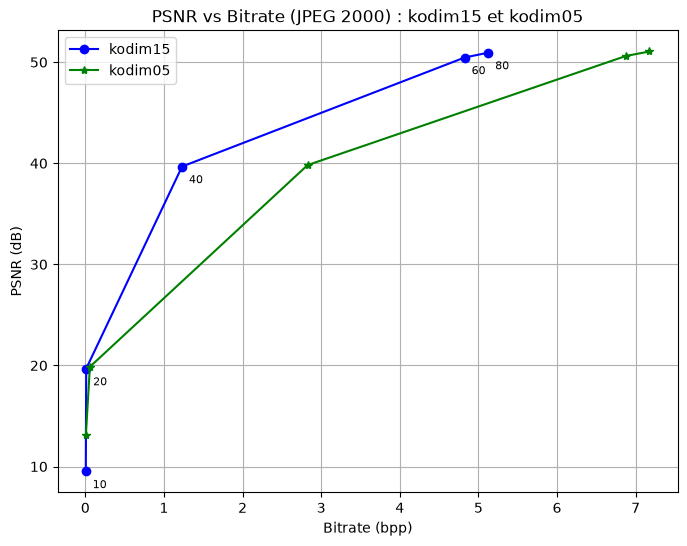

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", linestyle="-", color="blue",  label="kodim15")
plt.plot(bitrates2, psnr_values2, marker="*", linestyle="-", color="green", label="kodim05")
for lv, x, y in zip(LEVELS, bitrates1, psnr_values1):
    plt.annotate(f"{lv}", (x, y), textcoords="offset points", xytext=(5, -12), fontsize=8)
plt.title("PSNR vs Bitrate (JPEG 2000) : kodim15 et kodim05")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "bitrate_PSNR_J2K.png"), dpi=150)
plt.show()

### 2.3 (Optionnel) Comparaison visuelle

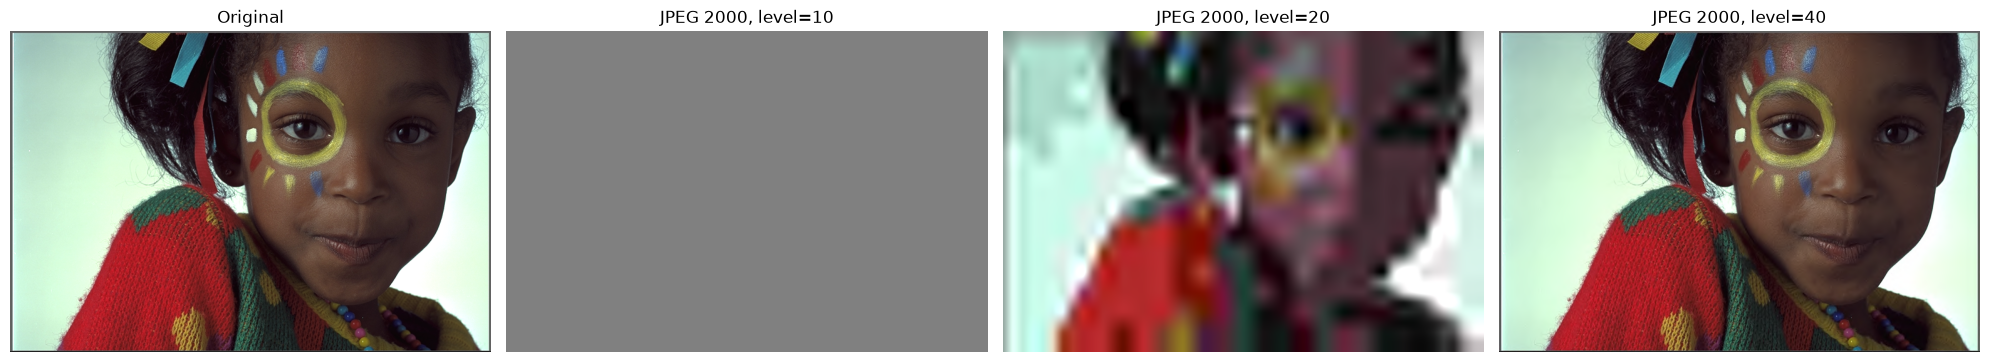

In [11]:
J = lire_uint8(os.path.join(DATA_DIR, "kodim15.png"))
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(J); axes[0].set_title("Original")
for ax, lv in zip(axes[1:], [10, 20, 40]):
    ax.imshow(imread(os.path.join(OUT_DIR, f"kodim15_TC{lv}_decoded.png")))
    ax.set_title(f"JPEG 2000, level={lv}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.4 (Optionnel) Comparaison avec JPEG (TP1)

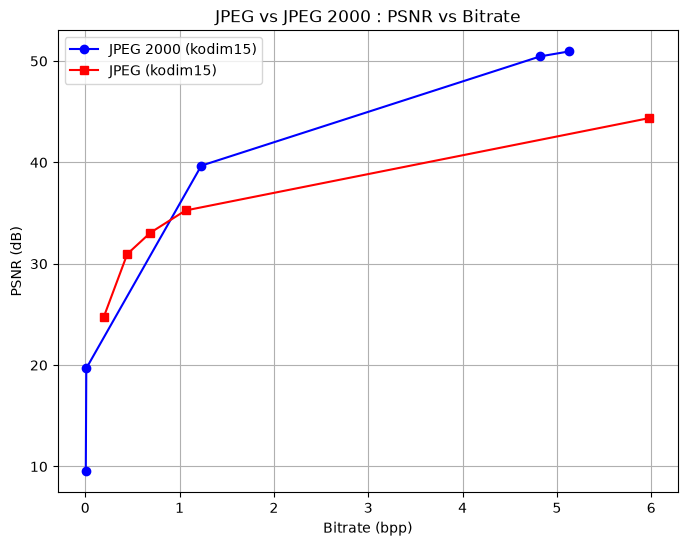

In [12]:
QUALITIES = [5, 25, 50, 75, 100]

def evaluer_jpeg(nom_image, qualities=QUALITIES):
    original = Image.open(os.path.join(DATA_DIR, nom_image)).convert("RGB")
    ref = np.array(original)
    num_pixels = original.size[0] * original.size[1]
    br, ps = [], []
    for q in qualities:
        path = os.path.join(OUT_DIR, f"jpeg_{os.path.splitext(nom_image)[0]}_q{q}.jpg")
        original.save(path, "JPEG", quality=q)
        br.append(os.path.getsize(path) * 8 / num_pixels)
        ps.append(psnr(ref, np.array(Image.open(path).convert("RGB"))))
    return br, ps

br_jpg, ps_jpg = evaluer_jpeg("kodim15.png")

plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", color="blue", label="JPEG 2000 (kodim15)")
plt.plot(br_jpg, ps_jpg, marker="s", color="red", label="JPEG (kodim15)")
plt.title("JPEG vs JPEG 2000 : PSNR vs Bitrate")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "jpeg_vs_j2k.png"), dpi=150)
plt.show()